# Einfacher bAV Beitragsrechner
Die betriebliche Altersvorsorge ist eine zusätzliche Altersvorsorge über den Arbeitgeber, bei der ein teil des Gehalts entnommen und für die Rente angespart wird. Mit einem bAV Beitragsrechner kann man das Kapital/Rente bis zum Renteneintritt berechnen, beitragsabhängige oder zinsabhängige Vergleiche aufstellen oder um Versicherungs- und Pensionsprodukte zu kalkulieren. 

Eine Pensionskasse ist ein möglicher Akteur, der die bAV durchführen kann. Die Pensionskasse sammelt die Beiträge, investiert das Geld und zahlt in der Rente das Geld aus. Solch ein Unternehmen muss als Risiken abschätzen und investieren, Renten kalkulieren oder auch Sensitivitätsanalysen bezüglich des Zinses durchführen.

In diesem Notebook soll es um einen einfachen bAV Beitragsrechner gehen, um ein Grundverständnis für den mathematischen Hintergrund zu erlangen.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot
import seaborn as sns

#### Festsetzen der Variablen
Für den Rechner benötigen wir das monatliche Gehalt, die Beiträge (Arbeitnehmer/Arbeitgeber), Rendite bzw. Zins und die Laufzeit in Jahren.

In [55]:
gehalt = 60000
beitrag_arbeitnehmer_monatlich = 300
beitrag_arbeitgeber_monatlich = 50
rendite_jährlich = 0.03
laufzeit_jahre = 35

## Aufstellen des bAV-Beitragsrechner

In [56]:
gesamtbeitrag_monatlich = beitrag_arbeitnehmer_monatlich + beitrag_arbeitgeber_monatlich
rendite_monatlich = rendite_jährlich / 12
monate = laufzeit_jahre * 12

Dann ergibt sich für den einfachen bAV Beitragsrechner folgende Formel für das Endkapital:

In [57]:
endkapital = (
    gesamtbeitrag_monatlich *
    (((1 + rendite_monatlich) ** monate - 1) / rendite_monatlich)
)
endkapital

259547.27995094436

### Kapitalentwicklung simulieren

Nun betrachten wir die Entwicklung des Kapitals über den Zeitraum hinweg unter der Voraussetzung eines konstanten Zins und konstanten Beiträgen. Dazu entwickeln wir eine Liste, die mit Kapital 0 startet. 

In [58]:
kapitalentwicklung = []
kapital = 0

for monat in range(monate):
    kapital *= (1 + rendite_monatlich)
    kapital += gesamtbeitrag_monatlich
    kapitalentwicklung.append(kapital)

Als nächstes Entwickeln wir daraus ein DataFrame mit dem Gesamtkapitel zu dem jeweiligen Monat bzw. Jahr.

In [59]:
df = pd.DataFrame({
    "Monat": np.arange(1, monate + 1),
    "Kapital": kapitalentwicklung
})
df["Jahr"] = df["Monat"] / 12
print(df.head())
print(df.tail())

   Monat      Kapital      Jahr
0      1   350.000000  0.083333
1      2   700.875000  0.166667
2      3  1052.627187  0.250000
3      4  1405.258755  0.333333
4      5  1758.771902  0.416667
     Monat        Kapital       Jahr
415    416  255576.654542  34.666667
416    417  256565.596178  34.750000
417    418  257557.010169  34.833333
418    419  258550.902694  34.916667
419    420  259547.279951  35.000000


### Kapitalentwicklung simulieren

<Axes: xlabel='Monat', ylabel='Kapital'>

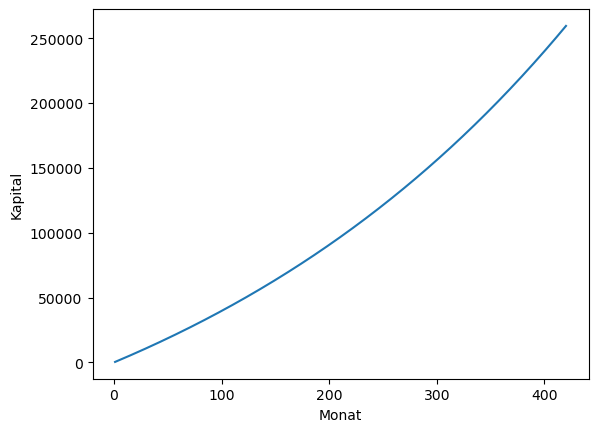

In [60]:
sns.lineplot(x = "Monat", y="Kapital", data=df)

Nach 35 Jahren beträgt das Endkapital 259547 Euro bei einem konstanten Zins von 3% und einem Gesamtbeitrag von 350 Euro.